# Developing a Model

First, install the required R packages if not done already. See [Installing Required R Packages](../../R/Install_R_Packages.ipynb).

In VS Code, if prompted to select a kernel, choose **Jupyter Kernel...** and select the **Recommended** R environment.

<br>

This notebook is a continuation meant to be viewed after the Data Exploration and Data Pre-Processing notebooks. In this notebook we will develop and assess various models and address some of the issues we've identified in our data exploration for model development.

## Loading Libraries

In the next section we will load the necessary libraries and dataset that will be used throughout this project.

In [20]:
library(glmnet)
library(dplyr)
library(xgboost)
library(pROC)
library(randomForest)

In [21]:
# Imports the dataset

train_final <- read.csv("../../data/output/customer_churn_ml_train_final.csv")
test_final <- read.csv("../../data/output/customer_churn_ml_test_final.csv")

names(train_final)
names(test_final)

[1] "trainID"                     "y_train"                    
 [3] "regionPctCustomers"          "numOfTotalReturns"          
 [5] "wksSinceLastPurch"           "basktPurchCount12Month"     
 [7] "LastPurchaseAmount"          "AvgPurchaseAmount12"        
 [9] "AvgPurchaseAmountTotal"      "intAdExposureCount12"       
[11] "intAdExposureCount36"        "socialMediaAdCount12"       
[13] "socialMediaAdCount36"        "socialMediaAdCountAll"      
[15] "totalNumProdPurchased"       "custInitiatedContacts"      
[17] "customersales"               "wksSinceFirstPurch"         
[19] "EstimatedIncome"             "regionMedHomeVal"           
[21] "techSupportEval"             "customerAge"                
[23] "AvgPurchasePerAd"            "LOGLastPurchaseAmount"      
[25] "LOGAvgPurchaseAmount12"      "LOGAvgPurchaseAmountTotal"  
[27] "LOGcustomersales"            "LOGAvgPurchasePerAd"        
[29] "customerGender.F"            "customerGender.M"           
[31] "customerSubscrStat.Gold"     "customerSubscrStat.Platinum"
[33] "demHomeOwner.HomeOwner"

[1] "testID"                      "y_test"                     
 [3] "regionPctCustomers"          "numOfTotalReturns"          
 [5] "wksSinceLastPurch"           "basktPurchCount12Month"     
 [7] "LastPurchaseAmount"          "AvgPurchaseAmount12"        
 [9] "AvgPurchaseAmountTotal"      "intAdExposureCount12"       
[11] "intAdExposureCount36"        "socialMediaAdCount12"       
[13] "socialMediaAdCount36"        "socialMediaAdCountAll"      
[15] "totalNumProdPurchased"       "custInitiatedContacts"      
[17] "customersales"               "wksSinceFirstPurch"         
[19] "EstimatedIncome"             "regionMedHomeVal"           
[21] "techSupportEval"             "customerAge"                
[23] "AvgPurchasePerAd"            "LOGLastPurchaseAmount"      
[25] "LOGAvgPurchaseAmount12"      "LOGAvgPurchaseAmountTotal"  
[27] "LOGcustomersales"            "LOGAvgPurchasePerAd"        
[29] "customerGender.F"            "customerGender.M"           
[31] "customerSubscrStat.Gold"     "customerSubscrStat.Platinum"
[33] "demHomeOwner.HomeOwner"

In [22]:
# Changes column names of ID and LostCustomer variables
colnames(train_final)[1]<- "ID"
colnames(test_final)[1]<- "ID"
colnames(train_final)[2]<- "LostCustomer"
colnames(test_final)[2]<- "LostCustomer"

In [23]:
# Separate the target and input variable names
target <- "LostCustomer"
inputs <- setdiff(names(train_final), c(target, "ID"))

target
inputs

[1] "LostCustomer"

[1] "regionPctCustomers"          "numOfTotalReturns"          
 [3] "wksSinceLastPurch"           "basktPurchCount12Month"     
 [5] "LastPurchaseAmount"          "AvgPurchaseAmount12"        
 [7] "AvgPurchaseAmountTotal"      "intAdExposureCount12"       
 [9] "intAdExposureCount36"        "socialMediaAdCount12"       
[11] "socialMediaAdCount36"        "socialMediaAdCountAll"      
[13] "totalNumProdPurchased"       "custInitiatedContacts"      
[15] "customersales"               "wksSinceFirstPurch"         
[17] "EstimatedIncome"             "regionMedHomeVal"           
[19] "techSupportEval"             "customerAge"                
[21] "AvgPurchasePerAd"            "LOGLastPurchaseAmount"      
[23] "LOGAvgPurchaseAmount12"      "LOGAvgPurchaseAmountTotal"  
[25] "LOGcustomersales"            "LOGAvgPurchasePerAd"        
[27] "customerGender.F"            "customerGender.M"           
[29] "customerSubscrStat.Gold"     "customerSubscrStat.Platinum"
[31] "demHomeOwner.HomeOwner"

In [24]:
# Isolate the target variable values and create x matrix to use in models
y_train <- train_final[[target]]
formula <- as.formula(paste(target, "~", paste(inputs, collapse = " + ")))
x_train <- model.matrix(formula, data = train_final)[, -1] 

## Benchmark Logistic Regression Model

In [25]:
# Fit with cross-validation to pick best lambda
model_logit <- cv.glmnet(x_train, y_train, family = "binomial", alpha = .5)

# Best lambda
best_lambda <- model_logit$lambda.min

In [26]:
# Prepare test matrix
x_test <- model.matrix(formula, data = test_final)[, -1]
y_test <- test_final[[target]]

# Predict probabilities
pred_logit <- predict(model_logit, newx = x_test, s = best_lambda, type = "response")

## Gradient Boosting Model

In [27]:
# Parameters 
params <- list(
  objective = "binary:logistic",
  max_depth = 5,                  
  eta = 0.1,                      
  eval_metric = "auc"                
)

# Convert to DMatrix 
dtrain <- xgb.DMatrix(data = x_train, label = y_train)

# Train the model 
gb_model <- xgb.train(
  params = params,
  data = dtrain,
  nrounds = 100, 
  verbose = 0
)

In [28]:
# Prepare test matrix
dtest <- xgb.DMatrix(data = as.matrix(x_test), label = y_test)

# Predict probabilities
pred_gb <- predict(gb_model, dtest)

## Random Forest

In [29]:
# Fit random forest
rf_model <- randomForest(
  x = as.data.frame(x_train),
  y = as.factor(y_train),
  ntree = 200,     
  mtry = floor(sqrt(ncol(x_train))) 
)

# Predict probabilities
pred_rf <- predict(rf_model, newdata = as.data.frame(x_test), type = "prob")[,2]

## Model Comparison

ROC curves are used to assess the performance of each model in predicting events.

In [30]:
# Logistic regression ROC
roc_logit <- roc(y_test, as.numeric(pred_logit))

# Gradient boosting ROC
roc_gb <- roc(y_test, as.numeric(pred_gb))

# Random Forest ROC
roc_rf <- roc(y_test, as.numeric(pred_rf))

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases



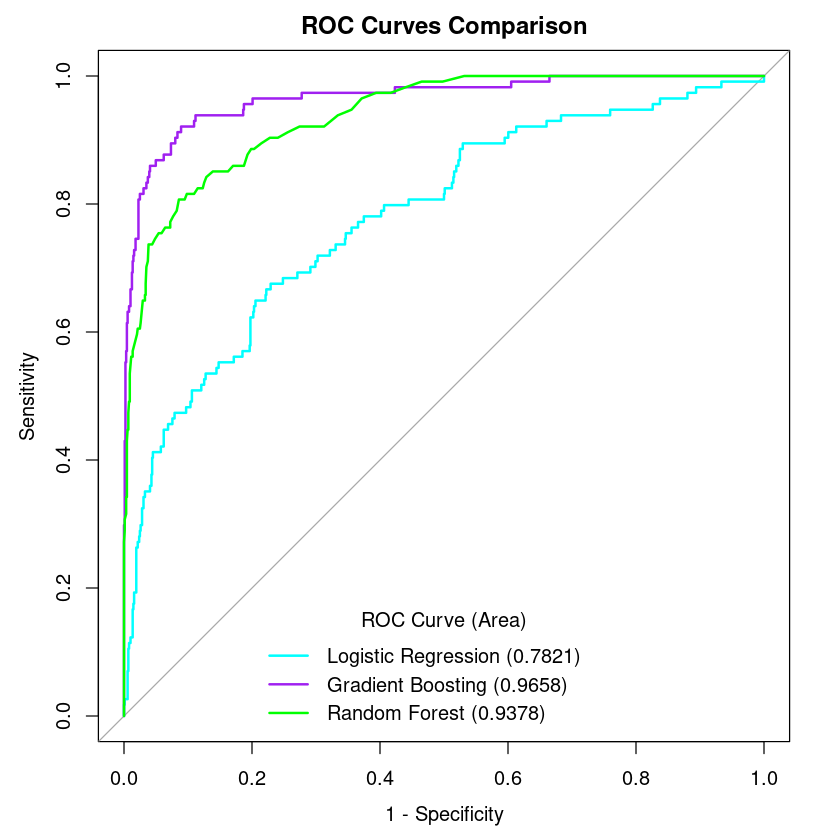

In [31]:
plot(roc_logit, col="cyan", lwd=2, main="ROC Curves Comparison", legacy.axes=TRUE)
lines(roc_gb, col="purple", lwd=2)
lines(roc_rf, col="green", lwd=2)
legend("bottom", title="ROC Curve (Area)",
       legend=c(paste0("Logistic Regression (", round(auc(roc_logit), 4),")"), paste0("Gradient Boosting (", round(auc(roc_gb), 4),")"), paste0("Random Forest (", round(auc(roc_rf), 4),")")),
       col=c("cyan", "purple", "green"),
       lwd=2, 
       bty = "n")


## Model Performance Statistics

Calculate accuracy, sensitivity, and specificity for each model.

In [32]:
# Calculating best threshold values for each model

best_thresh_logit <- as.numeric(coords(roc_logit, "best", ret="threshold", best.method="youden"))
best_thresh_gb <- as.numeric(coords(roc_gb, "best", ret="threshold", best.method="youden"))
best_thresh_rf <- as.numeric(coords(roc_rf, "best", ret="threshold", best.method="youden"))

best_thresh_logit
best_thresh_gb
best_thresh_rf

[1] 0.1402262

[1] 0.107708

[1] 0.2125

In [33]:
true_labels <- y_test

modelPerformance <- function(pred_probs, best_threshold, model_name){
  pred_labels <- ifelse(pred_probs >= best_threshold, 1, 0)
  conf_mat <- table(Predicted = pred_labels, Actual = true_labels)

  TP <- conf_mat["1","1"]
  TN <- conf_mat["0","0"]
  FP <- conf_mat["1","0"]
  FN <- conf_mat["0","1"]

  accuracy <- (TP + TN) / sum(conf_mat)
  sensitivity <- TP / (TP + FN)
  specificity <- TN / (TN + FP)

  metrics <- data.frame(
    Model = model_name,
    Accuracy = accuracy,
    Sensitivity = sensitivity,
    Specificity = specificity,
    TP = TP,
    TN = TN,
    FP = FP,
    FN = FN
  )

  return(metrics)
}

# Now call:
df_logit <- modelPerformance(pred_logit, best_thresh_logit, "Logistic Regression")
df_gb <- modelPerformance(pred_gb,best_thresh_gb, "Gradient Boosting")
df_rf <- modelPerformance(pred_rf, best_thresh_rf, "Random Forest")

# Combine all
all_models <- rbind(df_logit, df_gb, df_rf)
print(all_models)

                Model Accuracy Sensitivity Specificity  TP  TN  FP FN
1 Logistic Regression    0.760   0.6754386   0.7708804  77 683 203 37
2   Gradient Boosting    0.912   0.9210526   0.9108352 105 807  79  9
3       Random Forest    0.902   0.8070175   0.9142212  92 810  76 22


## Saving the Champion Model for Deployment

In [34]:
# saving model
save(gb_model, file="../../models/outmodel.rda")

In [35]:
# loading model
load("../../models/outmodel.rda")

In [36]:
# predictions
new_preds <- predict(gb_model, dtest)
head(new_preds)

[1] 0.734514058 0.045541972 0.011725727 0.025740575 0.006039997 0.006283917

In [37]:
# creating predictions data frame to bind with data
rownames(pred_gb) <- NULL
gb_pred_df <- as.data.frame(pred_gb)
names(gb_pred_df)[1] <- "P_LostCustomer"

In [38]:
# binding testing data and predictions
data_gbpreds <- gb_pred_df %>%
  bind_cols(test_final) %>%  
  arrange(desc(P_LostCustomer))

head(data_gbpreds, 40)

,P_LostCustomer,ID,LostCustomer,regionPctCustomers,numOfTotalReturns,wksSinceLastPurch,basktPurchCount12Month,LastPurchaseAmount,AvgPurchaseAmount12,AvgPurchaseAmountTotal,⋯,LOGLastPurchaseAmount,LOGAvgPurchaseAmount12,LOGAvgPurchaseAmountTotal,LOGcustomersales,LOGAvgPurchasePerAd,customerGender.F,customerGender.M,customerSubscrStat.Gold,customerSubscrStat.Platinum,demHomeOwner.HomeOwner
,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>
1,0.9613071,139626,1,1.73196652,0.9982966,0.005883269,-1.3850794,60,53.15,51.05,⋯,-0.313228196,-2.463648e-01,-0.38097012,-1.31172697,-0.67587431,0,1,0,1,0
2,0.9593287,64983,1,0.24670612,-0.3423737,-0.210016526,0.9272401,100,100.00,100.00,⋯,0.386271715,4.626391e-01,0.95718534,0.49913240,0.79352388,1,0,1,0,0
3,0.9561270,151547,1,0.85828393,-1.0127088,1.085382246,3.8176395,75,0.00,75.00,⋯,-0.008235227,-4.786535e+00,0.38312405,-2.23185457,-3.19123775,0,1,1,0,1
4,0.9508812,144309,1,-1.06381776,-0.3423737,-0.425916321,0.9272401,125,125.00,125.00,⋯,0.693070723,7.141850e-01,1.40361965,0.90442666,0.85530700,0,1,1,0,1
5,0.9416355,144729,1,0.42144264,0.9982966,0.005883269,-0.8069995,50,71.25,63.55,⋯,-0.561607083,8.162817e-02,0.05350188,-1.25025021,-0.08564808,0,1,0,1,1
6,0.9410781,161763,1,-2.72381468,0.3279615,0.005883269,-0.2289196,50,75.00,52.20,⋯,-0.561607083,1.391811e-01,-0.33685664,-0.63619877,-0.01328071,0,1,0,1,0
7,0.9403527,159507,1,0.85828393,-0.3423737,-0.425916321,0.9272401,100,100.00,100.00,⋯,0.386271715,4.626391e-01,0.95718534,0.49913240,0.52048923,1,0,1,0,1
8,0.9350550,156174,1,1.46986175,1.6686317,-0.425916321,-1.3850794,50,50.00,47.20,⋯,-0.561607083,-3.145310e-01,-0.53609028,-1.32388820,-0.66562981,0,1,0,1,1
9,0.9333385,146695,1,0.77091568,-0.3423737,-0.425916321,0.9272401,100,100.00,100.00,⋯,0.386271715,4.626391e-01,0.95718534,0.49913240,0.52048923,1,0,1,0,1
